# Annoter des images, mesurer l'accord entre annotateurs, réviser le guide

Dans cette démonstration, le groupe va :

1. écrire un premier guide d'annotation pour classer des photos de paysages ;
2. annoter 10 photos en suivant ce guide ;
3. mesurer l'accord entre les annotateurs ;
4. réviser le guide à partir des photos qui ont divisé le groupe ;
5. annoter à nouveau les photos, puis comparer les deux mesures.

C'est la boucle d'écriture d'un guide d'annotation : une version, l'annotation, la détection des points ambigus, une nouvelle version.

Les cellules contiennent des annotations d'exemple, pour que le notebook tourne tel quel.

## Récupération des données

In [1]:
import pathlib

!rm -rf sample_data

if not pathlib.Path("landscape").is_dir():
  !wget -qO- https://github.com/shuuchuu/datasets/raw/refs/heads/main/ghsparse.sh | bash -s landscape

!mkdir -p to-annotate

ids = [10034, 10159, 10244, 1060, 1072, 11, 11105, 1223, 12326, 12971]
for i, id in enumerate(ids):
  !cp landscape/seg_pred/no_supervision/{id}.jpg to-annotate/{i}.jpg

La cellule suivante définit les outils de la démonstration (affichage des images, lecture des annotations, calcul de l'accord). Exécutez-la, il n'est pas nécessaire de lire son code.

In [2]:
#@title Outils de la démonstration (exécutez la cellule, inutile de lire son code)
import math
import pathlib
import random
import re

import matplotlib.pyplot as plt
import numpy
import statsmodels.stats.inter_rater
from PIL import Image

classes = ["buildings", "forest", "glacier", "mountain", "sea", "street"]
# Les noms de classes en français sont acceptés aussi
aliases = {
  "bâtiments": "buildings", "bâtiment": "buildings", "batiments": "buildings", "batiment": "buildings",
  "forêt": "forest", "foret": "forest",
  "montagne": "mountain",
  "mer": "sea",
  "rue": "street", "route": "street",
}
images = sorted(pathlib.Path("to-annotate").glob("*.jpg"), key=lambda path: int(path.stem))


def show_examples(per_class=6):
  """Affiche des images de chaque classe, tirées au hasard dans le jeu d'entraînement."""
  random.seed(0)
  fig, axes = plt.subplots(len(classes), per_class, figsize=(2 * per_class, 2.2 * len(classes)))
  for row, name in zip(axes, classes):
    paths = random.sample(sorted(pathlib.Path("landscape/seg_train", name).glob("*.jpg")), per_class)
    for ax, path in zip(row, paths):
      ax.imshow(Image.open(path))
      ax.axis("off")
    row[0].set_title(name, loc="left", fontweight="bold")
  plt.tight_layout()
  plt.show()


def show_images(order=None, titles=None, colors=None):
  """Affiche les images à annoter, dans l'ordre donné, avec les titres et couleurs donnés."""
  order = list(range(len(images))) if order is None else order
  rows = math.ceil(len(order) / 5)
  fig, axes = plt.subplots(rows, 5, figsize=(15, 3.6 * rows), squeeze=False)
  for ax in axes.flat:
    ax.axis("off")
  for ax, i in zip(axes.flat, order):
    ax.imshow(Image.open(images[i]))
    ax.set_title(f"Image {i}" if titles is None else titles[i], color="black" if colors is None else colors[i])
  plt.tight_layout()
  plt.show()


def read_annotations(text):
  """Lit les annotations collées depuis un tableur : une ligne par annotateur, son nom puis une classe par image."""
  annotations = {}
  for line in text.strip().splitlines():
    fields = line.split("\t") if "\t" in line else re.split(r"[\s,;]+", line)
    fields = [field.strip() for field in fields if field.strip()]
    if not fields:
      continue
    name = fields[0]
    labels = [aliases.get(label.lower(), label.lower()) for label in fields[1:]]
    unknown = [label for label in labels if label not in classes]
    if unknown:
      raise ValueError(f"{name} : classe(s) inconnue(s) {unknown}. Classes possibles : {classes}")
    if len(labels) != len(images):
      raise ValueError(f"{name} : {len(labels)} classe(s) au lieu de {len(images)}, une par image")
    annotations[name] = labels
  if len(annotations) < 2:
    raise ValueError("Il faut au moins deux annotateurs pour mesurer un accord")
  print(f"{len(annotations)} annotateurs : {', '.join(annotations)}")
  return annotations


def votes(annotations):
  """Compte, pour chaque image, combien d'annotateurs ont choisi chaque classe."""
  table = numpy.zeros((len(images), len(classes)), dtype=int)
  for labels in annotations.values():
    for i, label in enumerate(labels):
      table[i, classes.index(label)] += 1
  return table


def image_agreement(annotations):
  """Part des paires d'annotateurs qui ont choisi la même classe, pour chaque image."""
  table = votes(annotations)
  n = len(annotations)
  return ((table**2).sum(axis=1) - n) / (n * (n - 1))


def kappa(annotations):
  """Kappa de Fleiss : l'accord entre annotateurs, corrigé de l'accord dû au hasard."""
  return statsmodels.stats.inter_rater.fleiss_kappa(votes(annotations))


def describe(value):
  """Qualifie un kappa selon l'échelle indicative de Landis et Koch (1977)."""
  if value < 0:
    return "pire que le hasard"
  for threshold, word in [(0.2, "accord très faible"), (0.4, "accord faible"), (0.6, "accord modéré"), (0.8, "bon accord")]:
    if value <= threshold:
      return word
  return "très bon accord"


def report(annotations):
  """Affiche le kappa, puis les images de la moins consensuelle à la plus consensuelle."""
  value = kappa(annotations)
  print(f"Kappa de Fleiss : {value:.2f} ({describe(value)}), {len(annotations)} annotateurs, {len(images)} images")
  table = votes(annotations)
  agreement = image_agreement(annotations)
  order = sorted(range(len(images)), key=lambda i: agreement[i])
  titles = {}
  for i in order:
    counts = sorted(((table[i, j], name) for j, name in enumerate(classes) if table[i, j]), reverse=True)
    titles[i] = f"Image {i} · accord {agreement[i]:.0%}\n" + ", ".join(f"{name} {count}" for count, name in counts)
  colors = {i: "black" if agreement[i] == 1 else "tab:red" for i in order}
  disputed = [i for i in order if agreement[i] < 1]
  print(f"Images sans unanimité (en rouge) : {', '.join(map(str, disputed)) or 'aucune'}")
  show_images(order, titles, colors)
  return value


def compare(before, after):
  """Compare les kappas et l'accord sur chaque image entre deux tours d'annotation."""
  kappa_before, kappa_after = kappa(before), kappa(after)
  print(f"Kappa de Fleiss, tour 1 : {kappa_before:.2f} ({describe(kappa_before)})")
  print(f"Kappa de Fleiss, tour 2 : {kappa_after:.2f} ({describe(kappa_after)})")
  x = numpy.arange(len(images))
  fig, ax = plt.subplots(figsize=(10, 3.5))
  ax.bar(x - 0.2, image_agreement(before), width=0.4, label="Tour 1 (guide v1)")
  ax.bar(x + 0.2, image_agreement(after), width=0.4, label="Tour 2 (guide v2)")
  ax.set_xticks(x, [f"Image {i}" for i in x])
  ax.set_ylim(0, 1.05)
  ax.yaxis.set_major_formatter(lambda y, _: f"{y:.0%}")
  ax.set_ylabel("Paires d'annotateurs d'accord")
  ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1), ncol=2, frameon=False)
  plt.tight_layout()
  plt.show()

## Les données

Le jeu de données classe des photos de paysages en 6 classes : `buildings` (bâtiments), `forest` (forêt), `glacier`, `mountain` (montagne), `sea` (mer) et `street` (rue). Voici quelques exemples de chaque classe, tirés au hasard du jeu d'entraînement :

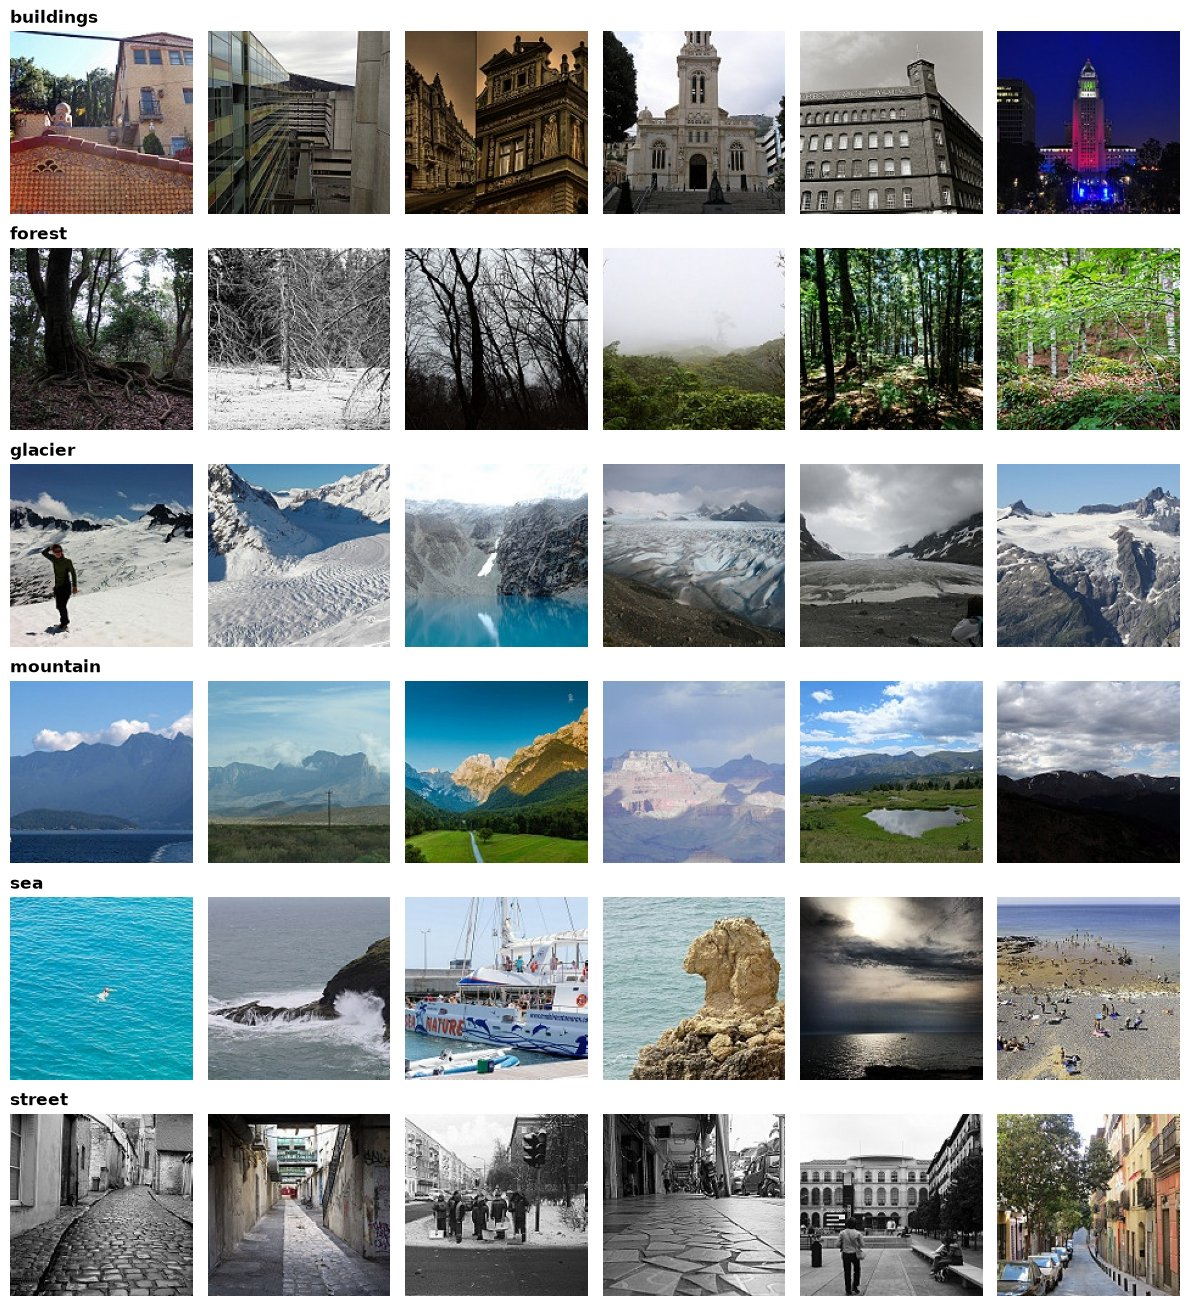

In [3]:
show_examples()

Et les 10 photos que le groupe va annoter, numérotées de 0 à 9 :

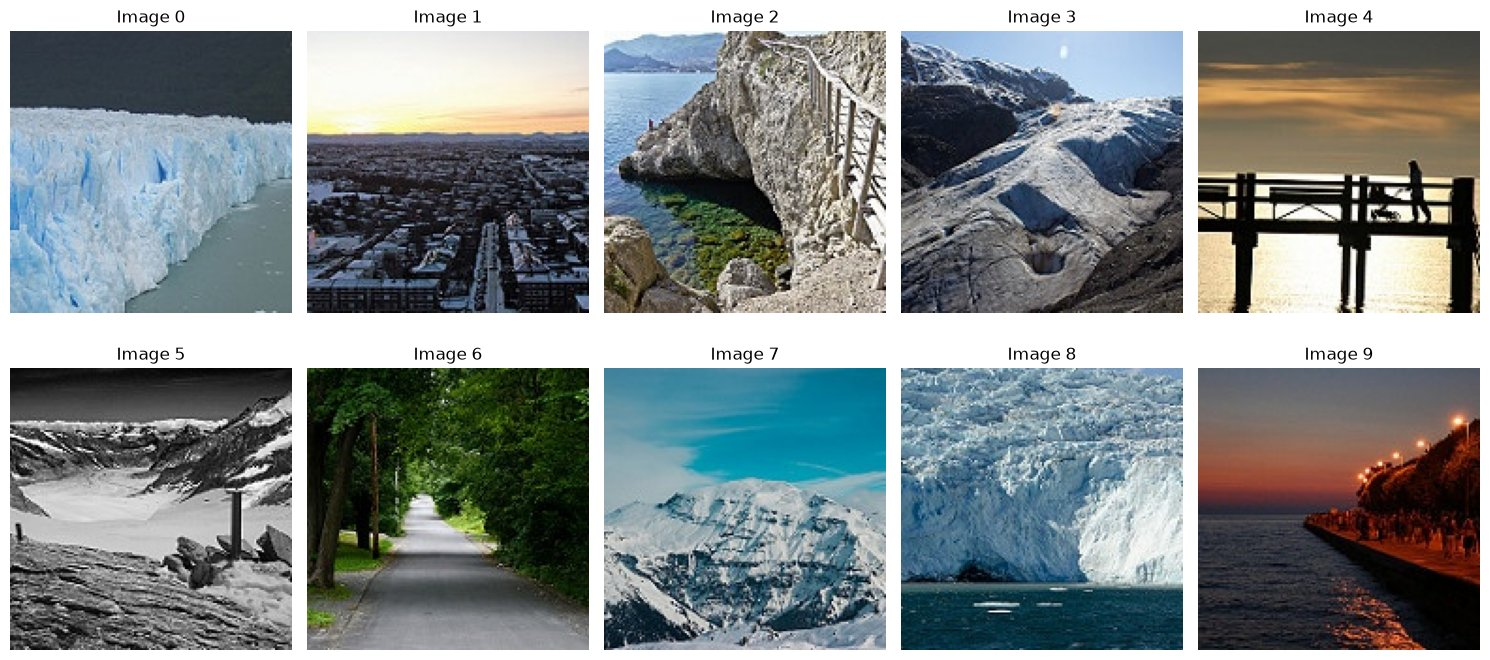

In [4]:
show_images()

## Guide d'annotation, version 1

À partir des exemples ci-dessus, le groupe écrit une première version du guide : une règle par classe, qui permette à quelqu'un qui n'a pas assisté à la discussion de choisir la classe d'une photo.

**Guide, version 1** (exemple)

- `buildings` : des bâtiments
- `forest` : des arbres
- `glacier` : de la glace ou de la neige
- `mountain` : des montagnes
- `sea` : la mer
- `street` : une rue ou une route

## Annotation, tour 1

Chaque participant annote les 10 photos en suivant le guide, sans en discuter avec les autres. Sur le support partagé (tableur ou formulaire), il donne son nom, puis une classe par photo, dans l'ordre de 0 à 9. Les noms de classes en français (`bâtiments`, `forêt`, `montagne`, `mer`, `rue`) sont acceptés.

In [5]:
# Une ligne par participant : son nom (en un mot) puis les 10 classes, séparés par des
# tabulations (copier-coller depuis un tableur), des virgules ou des espaces
annotations_v1 = read_annotations("""
Alice  glacier  buildings  sea       glacier   sea       glacier   forest  glacier   glacier  sea
Bruno  glacier  street     mountain  mountain  sea       mountain  street  mountain  glacier  street
Chloé  glacier  buildings  mountain  glacier   street    glacier   forest  glacier   glacier  sea
David  glacier  buildings  sea       mountain  buildings mountain  street  mountain  glacier  sea
Emma   glacier  street     sea       glacier   sea       glacier   forest  glacier   glacier  street
""")

5 annotateurs : Alice, Bruno, Chloé, David, Emma


## Mesurer l'accord entre annotateurs

Pour chaque photo, on regarde quelle part des paires d'annotateurs a choisi la même classe. Le **kappa de Fleiss** résume cet accord sur l'ensemble des photos, en le comparant à l'accord qu'on obtiendrait si chacun choisissait les classes au hasard (en respectant la fréquence de chaque classe dans les réponses) :

- 1 : accord parfait ;
- 0 : pas mieux que le hasard ;
- en dessous de 0 : moins d'accord que le hasard.

Il étend le kappa de Cohen, qui compare deux annotateurs, à un nombre quelconque d'annotateurs. Sa valeur dépend du nombre de classes et des photos choisies : il sert surtout à comparer deux mesures faites dans les mêmes conditions, comme ici avant et après la révision du guide. Le qualificatif affiché suit l'échelle de Landis et Koch (1977), qui n'est qu'indicative.

La figure montre les photos de la moins consensuelle à la plus consensuelle, avec les votes de chacune.

Kappa de Fleiss : 0.36 (accord faible), 5 annotateurs, 10 images
Images sans unanimité (en rouge) : 4, 1, 2, 3, 5, 6, 7, 9


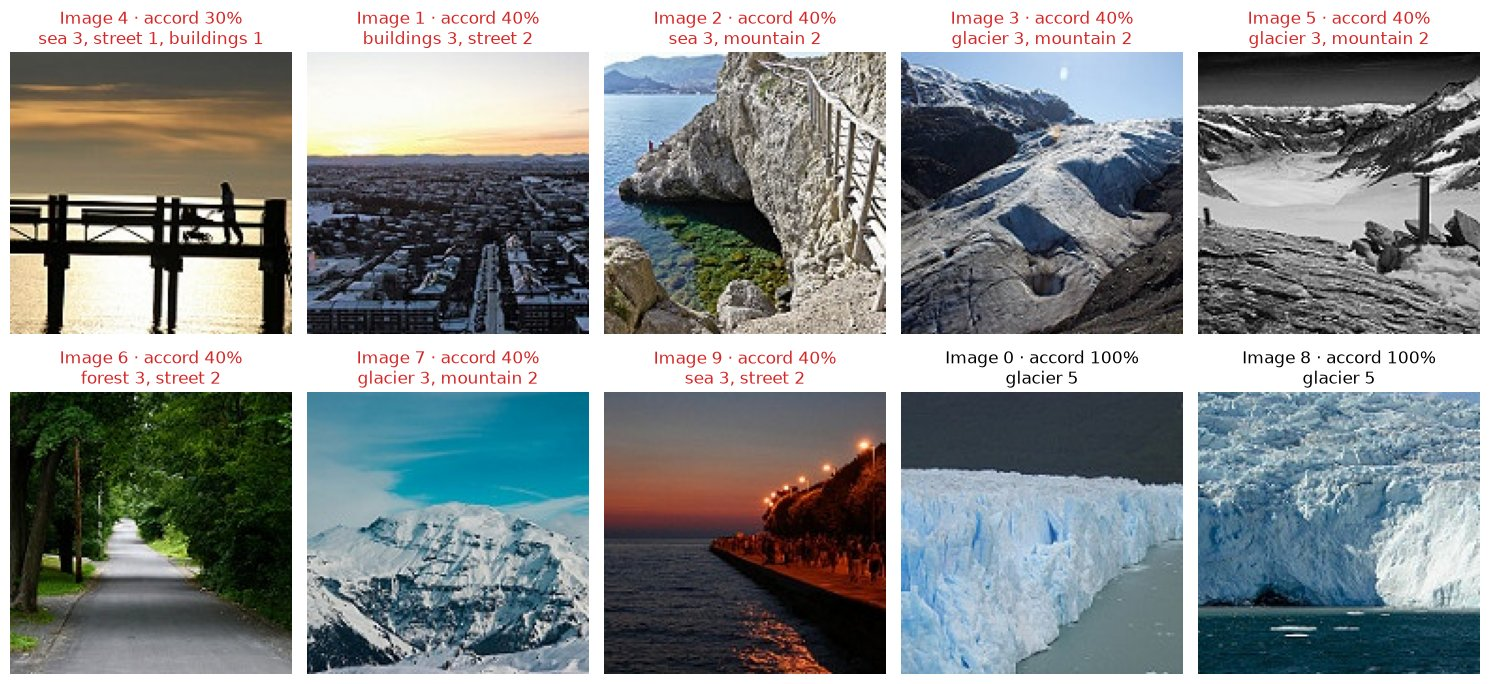

In [6]:
kappa_v1 = report(annotations_v1)

## Réviser le guide

Le groupe reprend les photos en rouge, en commençant par celles qui l'ont le plus divisé. Pour chacune :

- Quelle règle du guide était ambiguë, ou manquait ?
- Quelle règle aurait permis à tout le monde de choisir la même classe ?

Il en tire une version 2 du guide : des définitions qui tranchent explicitement les cas limites, et un ordre de priorité quand deux classes s'appliquent à la même photo.

Avec les annotations d'exemple, les désaccords portent sur la glace et la neige (glacier ou montagne ?), l'eau visible à côté d'autre chose (une jetée, une falaise, une promenade : mer ?) et les routes (rue, bâtiments ou forêt ?).

**Guide, version 2** (exemple)

Appliquez la première règle qui correspond à la photo :

1. `glacier` : une masse de glace (bleutée, fissurée, en langue ou en front) est bien visible. La neige sur des sommets ne suffit pas.
2. `sea` : l'eau (mer ou lac) occupe au moins un tiers de la photo, même avec une jetée, des falaises ou une promenade.
3. `mountain` : le relief (sommets, pentes, falaises) domine, enneigé ou non.
4. `street` : vue depuis le sol, une rue, une route ou un chemin mène dans la photo, même entre des arbres ou des bâtiments.
5. `buildings` : des bâtiments dominent, y compris une ville vue d'en haut.
6. `forest` : des arbres dominent, et aucune voie ne mène dans la photo.

## Annotation, tour 2

Chaque participant annote à nouveau les 10 photos, avec le guide révisé et toujours sans en discuter.

In [7]:
annotations_v2 = read_annotations("""
Alice  glacier  buildings  sea       glacier   sea  glacier   street  mountain  glacier  sea
Bruno  glacier  buildings  sea       glacier   sea  mountain  street  mountain  glacier  sea
Chloé  glacier  buildings  sea       glacier   sea  glacier   street  mountain  glacier  sea
David  glacier  buildings  mountain  glacier   sea  glacier   street  mountain  glacier  sea
Emma   glacier  buildings  sea       glacier   sea  glacier   street  mountain  glacier  street
""")

5 annotateurs : Alice, Bruno, Chloé, David, Emma


Kappa de Fleiss : 0.84 (très bon accord), 5 annotateurs, 10 images
Images sans unanimité (en rouge) : 2, 5, 9


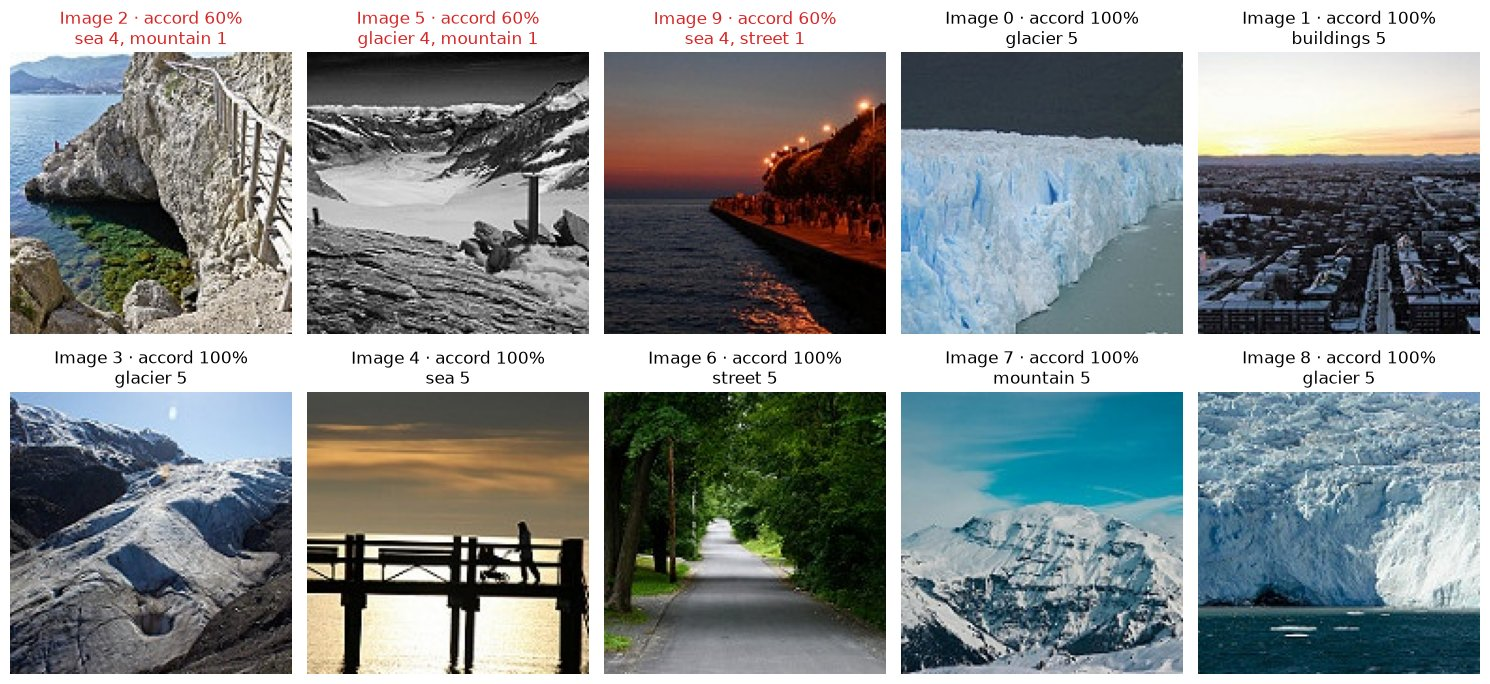

In [8]:
kappa_v2 = report(annotations_v2)

## Comparer les deux tours

Kappa de Fleiss, tour 1 : 0.36 (accord faible)
Kappa de Fleiss, tour 2 : 0.84 (très bon accord)


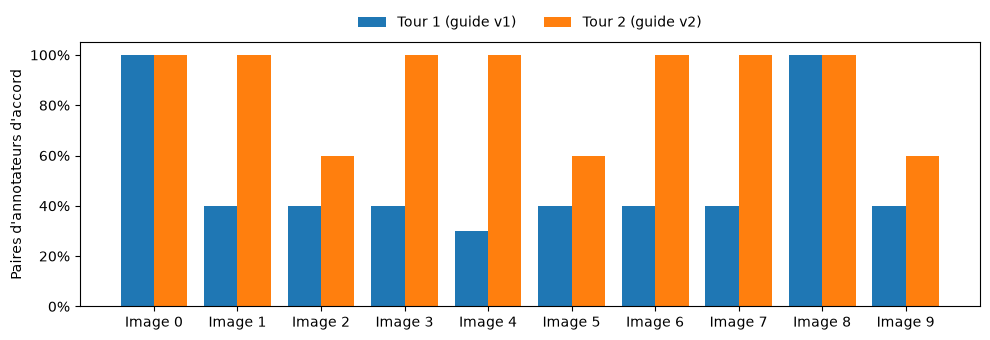

In [9]:
compare(annotations_v1, annotations_v2)

Si le guide révisé a levé les ambiguïtés, le kappa augmente. Deux précautions avant de conclure :

- Les participants ont annoté deux fois les mêmes photos, après en avoir discuté : une partie du gain vient de la discussion elle-même. Dans un vrai projet, on vérifie le nouveau guide sur des photos que personne n'a encore vues.
- Avec 10 photos et quelques annotateurs, la mesure est très incertaine : un seul vote change nettement le kappa.

Une photo sur laquelle le désaccord persiste est peut-être réellement ambiguë (elle relève de deux classes à la fois) : c'est une information sur le problème, pas seulement sur le guide. On peut alors la faire trancher par un expert, accepter plusieurs étiquettes, ou revoir la définition des classes.

## Impact sur le niveau de performance humain

Le niveau de performance humain (*Human Level Performance — HLP*) est très utilisé en Machine Learning. Quel est l'impact d'une mauvaise annotation sur le HLP ? Un algorithme d'apprentissage subit-il les mauvaises annotations de la même manière ?

Pistes pour la discussion :

- Le HLP se mesure en comparant les annotations d'un humain à une référence (ou à celles des autres annotateurs). Avec un guide ambigu, des annotateurs compétents se contredisent : le HLP mesuré baisse, mais il reflète alors l'incohérence des étiquettes plus que la difficulté réelle de la tâche. Il estime donc mal l'erreur de Bayes.
- Un modèle peut alors sembler « dépasser le niveau humain » simplement parce qu'il reproduit mieux l'étiquette majoritaire. Ce n'est pas un vrai progrès : clarifier le guide fait remonter le HLP et révèle la marge qui reste.
- Un algorithme d'apprentissage ne subit pas toutes les erreurs de la même manière :
  - des erreurs aléatoires et peu nombreuses se compensent en partie sur beaucoup d'exemples, mais elles demandent plus de données et abaissent les performances atteignables ;
  - des erreurs systématiques (par exemple, toujours appeler `glacier` une montagne enneigée) sont apprises telles quelles : le modèle reproduit fidèlement la règle implicite des annotateurs ;
  - des étiquettes bruitées dans le jeu de test rendent l'évaluation elle-même peu fiable.
- Améliorer la cohérence de l'annotation (guide, double annotation des cas ambigus) est souvent plus rentable que de changer de modèle.

## À retenir

- Un guide d'annotation s'écrit par itérations : une version, l'annotation, la détection des désaccords, une nouvelle version.
- Le kappa de Fleiss mesure l'accord entre plusieurs annotateurs, corrigé du hasard (1 : parfait, 0 : hasard). Il sert surtout à comparer deux mesures.
- Les désaccords montrent où le guide est ambigu, ou bien où les classes elles-mêmes se recouvrent.
- La qualité des étiquettes plafonne celle du modèle et la fiabilité de son évaluation. La mesurer coûte peu : quelques annotateurs sur un échantillon suffisent.